Ví dụ 1:

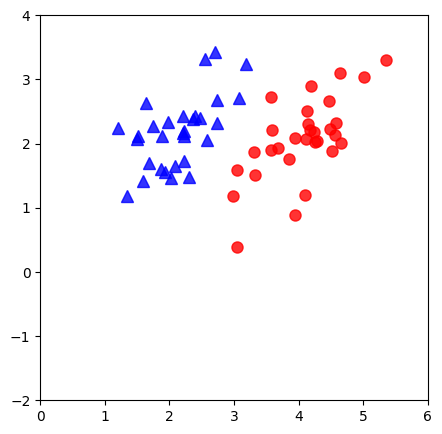

MovieWriter imagemagick unavailable; using Pillow instead.


[[ 13.97858527]
 [-15.02901929]
 [ 14.38743059]]


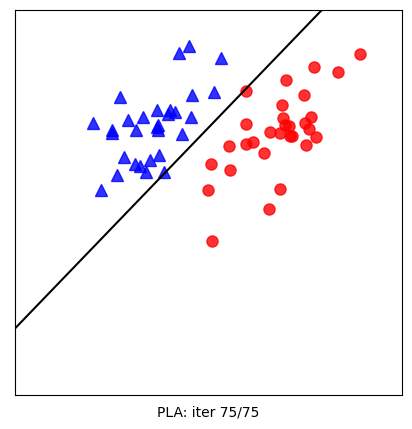

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2)
means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
N = 30
X0 = np.random.multivariate_normal(means[0], cov, N).T
X1 = np.random.multivariate_normal(means[1], cov, N).T
X = np.concatenate((X0, X1), axis = 1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1)
# Xbar
X = np.concatenate((np.ones((1, 2*N)), X), axis = 0)

fig, ax = plt.subplots(figsize=(5, 5))
ani = plt.cla()
#plot points
ani = plt.plot(X0[0, :], X0[1, :], 'b^', markersize = 8, alpha = .8)
ani = plt.plot(X1[0, :], X1[1, :], 'ro', markersize = 8, alpha = .8)
ani = plt.axis([0 , 6, -2, 4])
plt.show()

# Define h_w(x):= W^T.x + w_0 = \bar{W}^T . \bar{x}
def h(w, x):
    return np.sign(np.dot(w.T, x))
#Stop condition
def has_converged(X, y, w):
    return np.array_equal(h(w, X), y) #True if h(w, X) == y else False

def perceptron(X, y, w_init, maxcount):
    w = [w_init]
    N = X.shape[1]
    count = 0
    mis_points = [] # set of miss position points
    while True:
    # mix data
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(3, 1)
            yi = y[0, mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi*xi
                w.append(w_new)
        if has_converged(X, y, w[-1]) or count > maxcount:
            break
        count += 1
    return (w, mis_points)

d = X.shape[0]
w_init = np.random.randn(d, 1)
(w, m) = perceptron(X, y, w_init, 1000000)
print(w[-1])

def draw_line(w):
    w0, w1, w2 = w[0], w[1], w[2]
    if w2 != 0:
        x11, x12 = -100, 100
        return plt.plot([x11, x12], [-(w1*x11 + w0)/w2, -(w1*x12 + w0)/w2], 'k')
    else:
        x10 = -w0/w1
        return plt.plot([x10, x10], [-100, 100], 'k')

## Visualization
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
def viz_alg_1d_2(w):
    it = len(w)
    fig, ax = plt.subplots(figsize=(5, 5))
    def update(i):
        ani = plt.cla()
        #points
        ani = plt.plot(X0[0, :], X0[1, :], 'b^', markersize = 8, alpha = .8)
        ani = plt.plot(X1[0, :], X1[1, :], 'ro', markersize = 8, alpha = .8)
        ani = plt.axis([0 , 6, -2, 4])
        i2 = i if i < it else it-1
        ani = draw_line(w[i2])
        if i < it-1:
        # draw one misclassified point
            circle = plt.Circle((X[1, m[i]], X[2, m[i]]), 0.15, color='k', fill = False)
            ax.add_artist(circle)
        # hide axis
        cur_axes = plt.gca()
        cur_axes.axes.get_xaxis().set_ticks([])
        cur_axes.axes.get_yaxis().set_ticks([])
        label = 'PLA: iter %d/%d' %(i2, it-1)
        ax.set_xlabel(label)
        return ani, ax
    anim = FuncAnimation(fig, update, frames=np.arange(0, it + 2), interval=1000)
    # save
    anim.save('D:\pla_vis.gif', dpi = 100, writer = 'imagemagick')
    plt.show()
viz_alg_1d_2(w)

Ví dụ 2:

[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[[-4.     -4.      2.0802  1.3958  1.0828  4.2674  3.4967 -0.4626 -2.2857
   0.949   7.1564  6.604  12.2918 11.1937  3.5044 -4.0731 -2.5842 -3.458
   0.3089 -1.5689 -0.4406  1.5728  3.6917  4.5387  3.0634  3.5312  1.0701
  -1.1078  0.0155  4.3971  2.0145  2.9157 -6.6057  1.7849

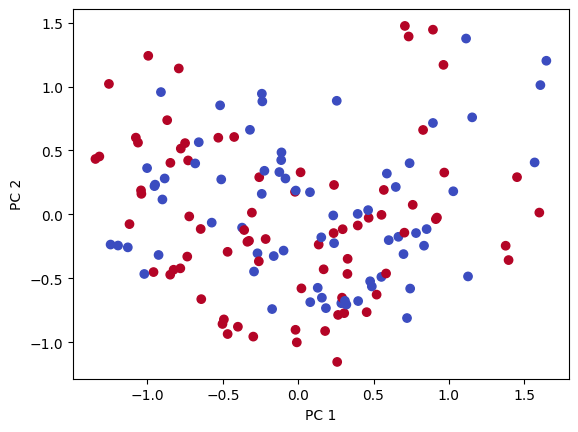

Accuracy of logistic regression: 0.57
Accuracy of perceptron: 0.48


In [2]:
from sklearn.model_selection import train_test_split
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score
import random

main_df = pd.read_csv(
    "D:\Code\Python\MachineLearning\Week_6\sonar.all-data.csv", header=None)
main_df

random.seed(10)
y_df = main_df[60]
targes_label = {'M': 1, 'R': -1}
targes_df = [targes_label[item] for item in y_df]
print(targes_df)

inputs_df = main_df.drop(60, axis=1)

inputs_df = main_df.drop(60, axis=1)
x0 = np.ones((inputs_df.shape[0], 1))
X = np.concatenate((x0, inputs_df), axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, targes_df, test_size=0.3, random_state=42)

pct = Perceptron()
#penalty ~ regularization : 'None';'l1';'l2'
#intercept = True => Xác định w_0 = b; = False => Bỏ qua
#Traning
Xbar = np.concatenate((np.ones((X_train.shape[0], 1)),X_train), axis=1)
pct.fit(Xbar,y_train)
print(pct.coef_)
Xtest = np.concatenate((np.ones((X_test.shape[0], 1)),X_test), axis=1)
y_pred = pct.predict(Xtest)
print("Use library:")
print("Accuracy = ", accuracy_score(y_test, y_pred))
print("Precision = ", precision_score(y_test, y_pred))
print("Recall = ", recall_score(y_test, y_pred))

# Define h_w(x):= W^T.x + w_0 = \bar{W}^T . \bar{x}
def h(w, x):
    return np.sign(np.dot(w.T, x))

def has_converged(X, y, w):
    return np.array_equal(h(w, X), y) #True if h(w, X) == y else False

def perceptron(X, y, w_init, maxcount):
    w = [w_init]
    N = X.shape[0]
    count = 0
    mis_points = [] # set of miss position points
    while True:
    # mix data
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(N, 1)
            yi = y[0, mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi*xi
                w.append(w_new)
        if has_converged(X, y, w[-1]) or count > maxcount:
            break
        count += 1
    return (w, mis_points)
d = Xbar.shape[1]
w_init = np.random.randn(d, 1)
(w, m) = perceptron(Xbar.T, np.array([y_train]), w_init, 10000)
y_pred = h(w[-1], Xtest.T)
print("Created:")
print("Accuracy = ", accuracy_score(y_test, y_pred[0]))
print("Precision = ", precision_score(y_test, y_pred[0]))
print("Recall = ", recall_score(y_test, y_pred[0]))

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(Xbar)
X_test_pca = pca.transform(Xtest)

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

from sklearn.linear_model import LogisticRegression

# logistic regression model
logreg = LogisticRegression()
logreg.fit(X_train_pca, y_train)

y_pred_logreg = logreg.predict(X_test_pca)
accuracy_logreg = np.mean(y_pred_logreg == y_test)

from sklearn.linear_model import Perceptron

# train perceptron model
perceptron = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
perceptron.fit(X_train_pca, y_train)

# evaluate model on test data
y_pred_perceptron = perceptron.predict(X_test_pca)
accuracy_perceptron = np.mean(y_pred_perceptron == y_test)
print('Accuracy of logistic regression: {:.2f}'.format(accuracy_logreg))
print('Accuracy of perceptron: {:.2f}'.format(accuracy_perceptron))

Ví dụ 3:

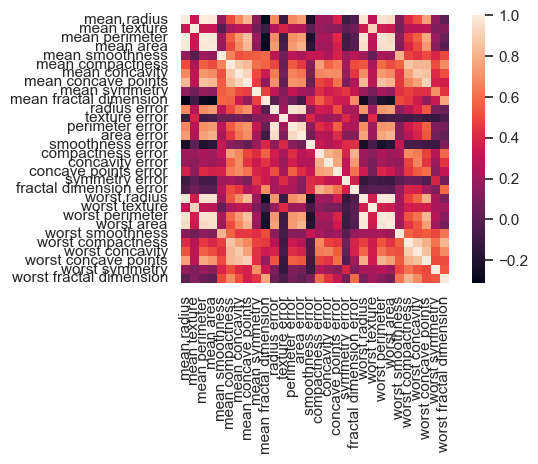

1    357
0    212
Name: target, dtype: int64


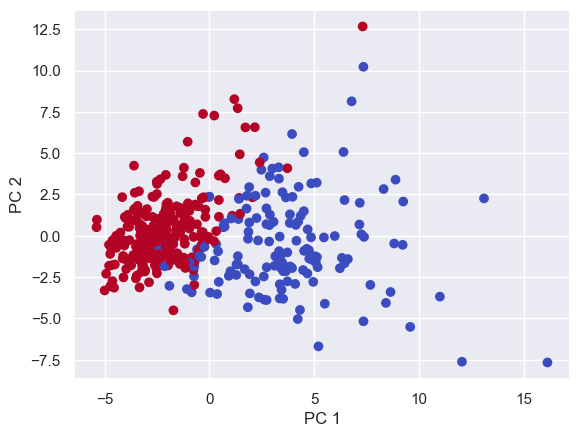

Accuracy of logistic regression: 0.98
Accuracy of perceptron: 0.95


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import numpy as np
import random

random.seed(10)
cancer = load_breast_cancer()
data = cancer.data
target = cancer.target

corr_matrix = np.corrcoef(data.T)
sns.set(font_scale=1.0)
hm = sns.heatmap(corr_matrix, cbar=True, annot=False, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cancer.feature_names, xticklabels=cancer.feature_names)
plt.tight_layout()
plt.show()

import pandas as pd

df = pd.DataFrame(data)
df['target'] = target

counts = df['target'].value_counts()
print(counts)
X = df.iloc[:, :-1].values
X = np.hstack((np.ones((X.shape[0], 1)), X))
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train_pca, y_train)
y_pred_logreg = logreg.predict(X_test_pca)
accuracy_logreg = np.mean(y_pred_logreg == y_test)

from sklearn.linear_model import Perceptron

perceptron = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
perceptron.fit(X_train_pca, y_train)

y_pred_perceptron = perceptron.predict(X_test_pca)
accuracy_perceptron = np.mean(y_pred_perceptron == y_test)
print('Accuracy of logistic regression: {:.2f}'.format(accuracy_logreg))
print('Accuracy of perceptron: {:.2f}'.format(accuracy_perceptron))

Ví dụ 4:

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

data = pd.read_csv('D:\Code\Python\MachineLearning\Week_6\\framingham.csv')

data.dropna(inplace=True)

data['male'] = pd.get_dummies(data['male'], drop_first=True)
data['education'] = data['education'].astype(int)
data['currentSmoker'] = pd.get_dummies(data['currentSmoker'], drop_first=True)
data['BPMeds'] = pd.get_dummies(data['BPMeds'], drop_first=True)
data['prevalentStroke'] = pd.get_dummies(data['prevalentStroke'], drop_first=True)
data['prevalentHyp'] = pd.get_dummies(data['prevalentHyp'], drop_first=True)
data['diabetes'] = pd.get_dummies(data['diabetes'], drop_first=True)

scaler = StandardScaler()
data[['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']] = scaler.fit_transform(data[['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']])

# Chia tập dữ liệu thành training set và validation set
train_data, val_data = train_test_split(data, test_size=0.3, random_state=42)

# Xác định biến đầu vào và biến đầu ra
X_train = train_data.drop(['TenYearCHD'], axis=1)
y_train = train_data['TenYearCHD']
X_val = val_data.drop(['TenYearCHD'], axis=1)
y_val = val_data['TenYearCHD']

# Huấn luyện mô hình Perceptron
perceptron = Perceptron(random_state=42)
perceptron.fit(X_train, y_train)

# Sử dụng mô hình để dự đoán trên tập validation set
y_pred = perceptron.predict(X_val)

# In ra kết quả
print('Use Perceptron: ')
print('Accuracy:', accuracy_score(y_val, y_pred))
print('Precision:', precision_score(y_val, y_pred))
print('Recall:', recall_score(y_val, y_pred))

# Khởi tạo mô hình Hồi quy Logistic
logreg = LogisticRegression(max_iter=10000)

# Huấn luyện mô hình trên tập huấn luyện
logreg.fit(X_train, y_train)

# Dự đoán nhãn trên tập validation
y_pred = logreg.predict(X_val)

# In kết quả các độ đo
print('Use Logistic Regression: ')
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))


Use Perceptron: 
Accuracy: 0.8359161349134002
Precision: 0.4444444444444444
Recall: 0.13793103448275862
Use Logistic Regression: 
Accuracy: 0.8468550592525068
Precision: 0.6071428571428571
Recall: 0.09770114942528736
